In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('faceit_matches.csv')
df.head()

,match_id,collected_at,map,t1_avg_elo,t1_elo_std,t1_min_elo,t1_max_elo,t1_avg_kd,t1_avg_hs_pct,t1_avg_win_rate,...,t2_avg_win_rate,t2_avg_matches,t2_avg_level,t2_avg_form,elo_diff,kd_diff,wr_diff,score_t1,score_t2,team1_win
0,1-169c7c63-7622-4c71-91b3-a7f7f4979d9e,2026-03-16T16:30:58.706670+00:00,de_nuke,2879.8,196.04,2686.0,3194.0,1.086,46.4,52.0,...,56.2,3084.8,9.8,0.52,22.8,-0.112,-4.2,16.0,14.0,1
1,1-e0880183-2880-4285-aa8d-f41b4af817c3,2026-03-16T16:31:09.469225+00:00,de_dust2,2818.6,404.15,2211.0,3303.0,1.206,48.8,53.8,...,55.8,3866.4,9.8,0.52,-74.6,-0.008,-2.0,11.0,13.0,0
2,1-85267fa4-9dcd-4598-9a7e-6569b70c87d2,2026-03-16T16:31:35.987438+00:00,de_nuke,2688.2,340.72,2197.0,3156.0,1.086,44.8,51.0,...,52.0,4007.4,10.0,0.80,-191.6,0.000,-1.0,8.0,13.0,0
3,1-96ec0c2c-4af5-4e45-a9b8-4ba16050eb9c,2026-03-16T16:31:43.755863+00:00,de_anubis,2750.2,251.65,2488.0,3039.0,1.120,48.4,51.2,...,51.6,3733.6,10.0,0.72,-7.0,0.048,-0.4,7.0,13.0,0
4,1-7a6a3cab-0bf9-46af-a68c-833635b1cb9c,2026-03-16T16:31:57.285271+00:00,de_dust2,2675.2,135.24,2496.0,2805.0,1.176,44.4,52.4,...,52.4,5789.6,10.0,0.60,-136.8,-0.018,0.0,17.0,19.0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1500 non-null   object 
 1   collected_at     1500 non-null   object 
 2   map              1500 non-null   object 
 3   t1_avg_elo       1500 non-null   float64
 4   t1_elo_std       1500 non-null   float64
 5   t1_min_elo       1500 non-null   float64
 6   t1_max_elo       1500 non-null   float64
 7   t1_avg_kd        1500 non-null   float64
 8   t1_avg_hs_pct    1500 non-null   float64
 9   t1_avg_win_rate  1500 non-null   float64
 10  t1_avg_matches   1500 non-null   float64
 11  t1_avg_level     1500 non-null   float64
 12  t1_avg_form      1500 non-null   float64
 13  t2_avg_elo       1500 non-null   float64
 14  t2_elo_std       1500 non-null   float64
 15  t2_min_elo       1500 non-null   float64
 16  t2_max_elo       1500 non-null   float64
 17  t2_avg_kd     

In [3]:
df.describe().round(2)

,t1_avg_elo,t1_elo_std,t1_min_elo,t1_max_elo,t1_avg_kd,t1_avg_hs_pct,t1_avg_win_rate,t1_avg_matches,t1_avg_level,t1_avg_form,...,t2_avg_win_rate,t2_avg_matches,t2_avg_level,t2_avg_form,elo_diff,kd_diff,wr_diff,score_t1,score_t2,team1_win
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,...,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,2377.45,191.09,2145.27,2614.83,1.13,48.12,51.75,2427.89,9.53,0.51,...,51.82,2403.78,9.52,0.52,3.28,0.00,-0.07,10.77,10.98,0.48
std,508.28,112.76,501.70,565.35,0.07,3.03,1.75,1450.57,1.09,0.14,...,2.13,1402.93,1.08,0.14,75.55,0.07,2.16,3.63,3.53,0.50
min,805.40,21.06,501.00,921.00,0.78,38.00,36.00,0.00,2.80,0.08,...,38.60,0.00,2.80,0.12,-468.80,-0.33,-22.20,0.00,0.00,0.00
25%,2082.55,110.38,1870.00,2268.00,1.09,46.20,50.80,1443.20,9.60,0.40,...,50.60,1420.65,9.60,0.40,-52.25,-0.04,-0.80,8.00,8.00,0.00
50%,2398.60,155.75,2150.50,2615.50,1.12,48.20,51.60,2112.40,10.00,0.52,...,51.60,2164.30,10.00,0.52,3.20,0.00,0.00,13.00,13.00,0.00
75%,2681.60,247.29,2483.50,2950.00,1.17,50.00,52.40,3109.20,10.00,0.60,...,52.40,3082.85,10.00,0.60,57.25,0.04,0.80,13.00,13.00,1.00
max,3887.40,758.74,3548.00,4674.00,2.65,56.40,69.00,10777.00,10.00,0.96,...,73.80,9583.40,10.00,0.96,337.60,1.47,16.60,28.00,26.00,1.00


# Data quality checks

null values

In [4]:
missing = df.isnull().sum()
print(missing)

match_id           0
collected_at       0
map                0
t1_avg_elo         0
t1_elo_std         0
t1_min_elo         0
t1_max_elo         0
t1_avg_kd          0
t1_avg_hs_pct      0
t1_avg_win_rate    0
t1_avg_matches     0
t1_avg_level       0
t1_avg_form        0
t2_avg_elo         0
t2_elo_std         0
t2_min_elo         0
t2_max_elo         0
t2_avg_kd          0
t2_avg_hs_pct      0
t2_avg_win_rate    0
t2_avg_matches     0
t2_avg_level       0
t2_avg_form        0
elo_diff           0
kd_diff            0
wr_diff            0
score_t1           0
score_t2           0
team1_win          0
dtype: int64


duplicates

In [5]:
dupes = df['match_id'].duplicated().sum()
print(dupes)

0


zero ELO check. 0 means that the data could not been fetched

In [6]:
zero_elo_t1 = (df['t1_avg_elo'] == 0).sum()
zero_elo_t2 = (df['t2_avg_elo'] == 0).sum()
print(zero_elo_t1)
print(zero_elo_t2)

0
0


# Graphs showing how wins are distributed

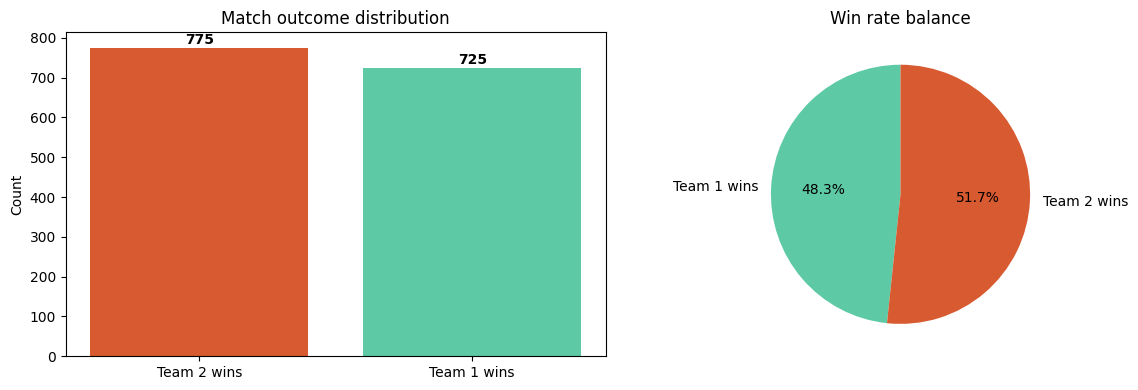

Team 1 win rate: 48.33%
Team 2 win rate: 51.67%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['team1_win'].value_counts()
colors = ['#D85A30', '#5DCAA5']

axes[0].bar(['Team 2 wins', 'Team 1 wins'], [counts[0], counts[1]], color=colors)
axes[0].set_title('Match outcome distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie([counts[1], counts[0]], labels=['Team 1 wins', 'Team 2 wins'],autopct='%1.1f%%', colors=colors[::-1], startangle=90)
axes[1].set_title('Win rate balance')

plt.tight_layout()
plt.show()

print(f'Team 1 win rate: {df["team1_win"].mean():.2%}')
print(f'Team 2 win rate: {1 - df["team1_win"].mean():.2%}')


# Team average ELO

team 1

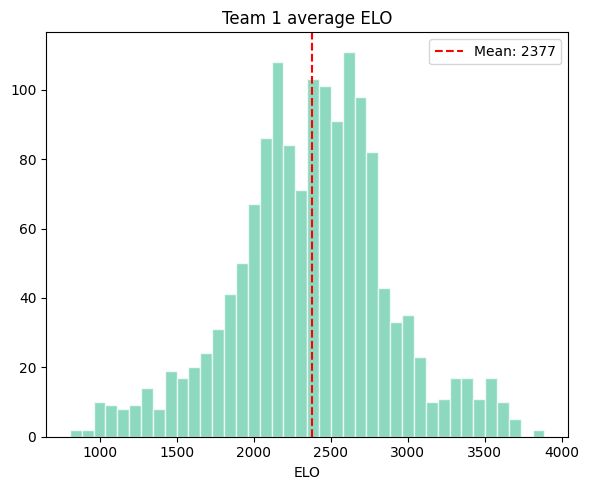

ELO range: 805 - 3887


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df['t1_avg_elo'], bins=40, color='#5DCAA5', alpha=0.7, edgecolor='white')
ax.axvline(df['t1_avg_elo'].mean(), color='red', linestyle='--',label=f'Mean: {df["t1_avg_elo"].mean():.0f}')
ax.set_title('Team 1 average ELO')
ax.set_xlabel('ELO')
ax.legend()

plt.tight_layout()
plt.show()

print(f'ELO range: {df["t1_avg_elo"].min():.0f} - {df["t1_avg_elo"].max():.0f}')


team 2

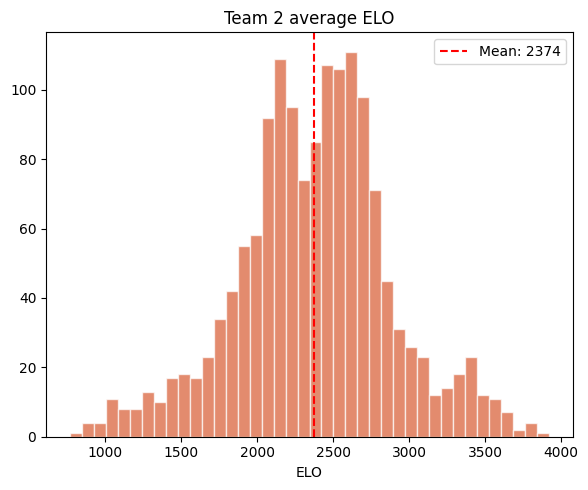

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df['t2_avg_elo'], bins=40, color='#D85A30', alpha=0.7, edgecolor='white')
ax.axvline(df['t2_avg_elo'].mean(), color='red', linestyle='--',label=f'Mean: {df["t2_avg_elo"].mean():.0f}')
ax.set_title('Team 2 average ELO')
ax.set_xlabel('ELO')
ax.legend()

plt.tight_layout()
plt.show()


difference between ELO between both teams againt each other

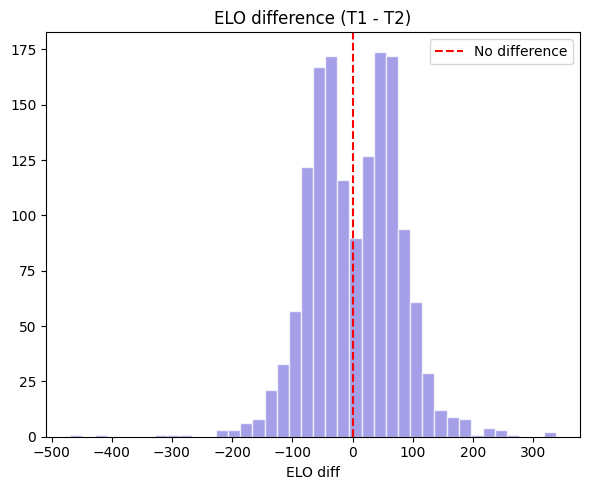

Mean ELO diff: 3.3 (close to 0 = matchmaking is balanced)


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df['elo_diff'], bins=40, color='#7F77DD', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='No difference')
ax.set_title('ELO difference (T1 - T2)')
ax.set_xlabel('ELO diff')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Mean ELO diff: {df["elo_diff"].mean():.1f} (close to 0 = matchmaking is balanced)')


# Graph showing how matches are distributed between maps

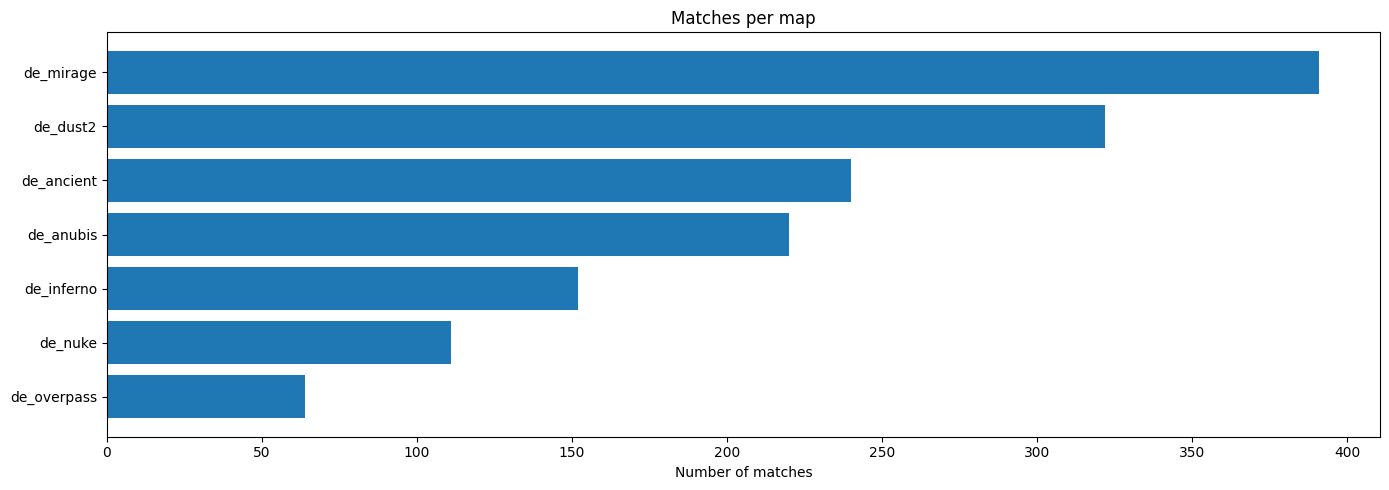

In [11]:
fig, axes = plt.subplots( figsize=(14, 5))

map_counts = df['map'].value_counts()
axes.barh(map_counts.index[::-1], map_counts.values[::-1])
axes.set_title('Matches per map')
axes.set_xlabel('Number of matches')


plt.tight_layout()
plt.show()

# Heatmap showing what data correlate the most ? to the team1 win

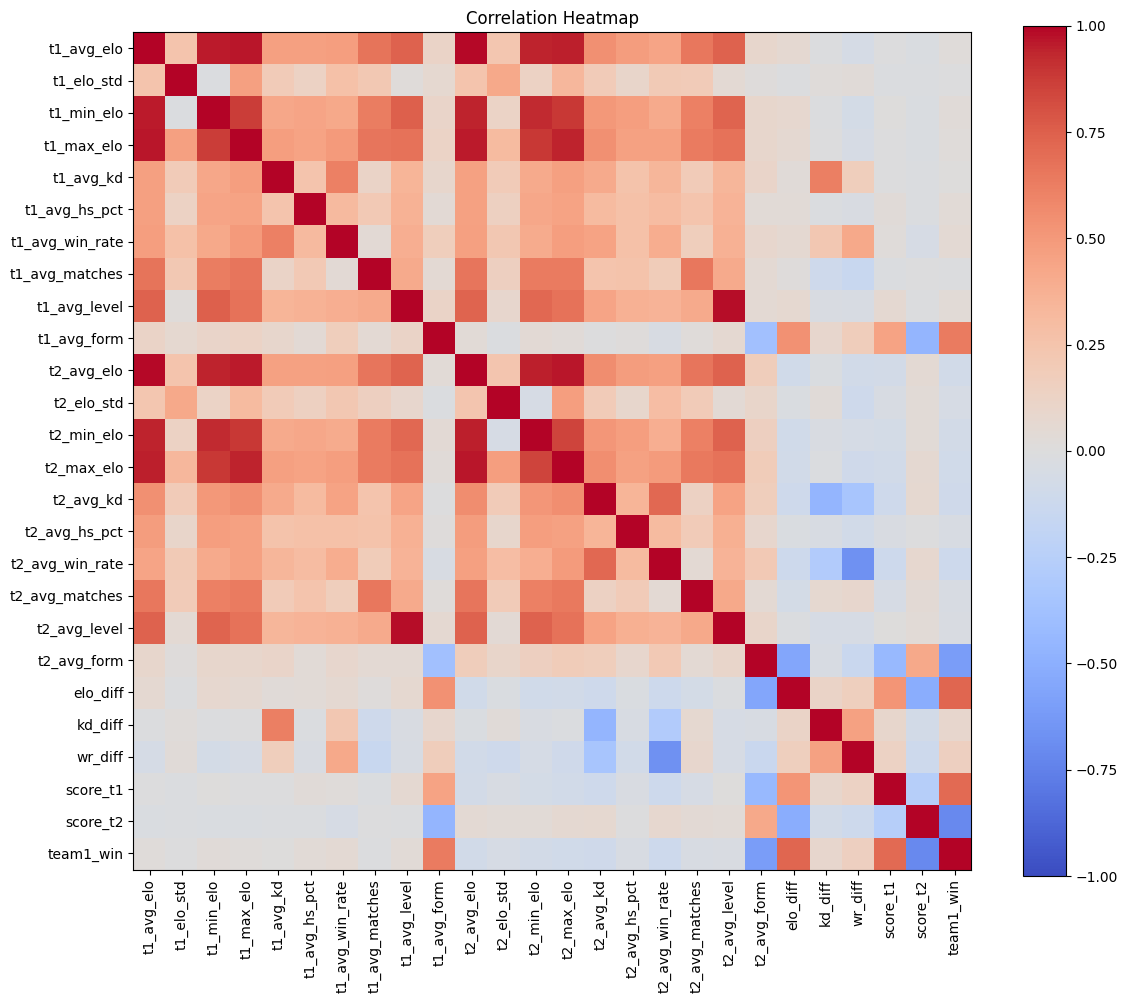

In [12]:

numeric_cols = df.select_dtypes(include=[np.number]).columns

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(cax, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# Data cleaning

Created a score_diff feature for regression

In [13]:
df['score_diff'] = df['score_t1'] - df['score_t2']


dropping feautures that we dont need

In [14]:
drop_cols = ['match_id', 'collected_at', 'score_t1', 'score_t2']
df = df.drop(columns=drop_cols)

creating new features that capture realtionships between team statistics

In [15]:
df['elo_ratio'] = df['t1_avg_elo'] / df['t2_avg_elo']
df['kd_ratio'] = df['t1_avg_kd'] / df['t2_avg_kd']
df['experience_ratio'] = df['t1_avg_matches'] / df['t2_avg_matches'].clip(lower=1)

df['elo_total'] = df['t1_avg_elo'] + df['t2_avg_elo']

df['elo_spread_diff'] = df['t1_elo_std'] - df['t2_elo_std']
df['hs_diff'] = df['t1_avg_hs_pct'] - df['t2_avg_hs_pct']
df['form_diff'] = df['t1_avg_form'] - df['t2_avg_form']
df['level_diff'] = df['t1_avg_level'] - df['t2_avg_level']

df['t1_consistency'] = 1 / (1 + df['t1_elo_std'])
df['t2_consistency'] = 1 / (1 + df['t2_elo_std'])

print('New features created:')
new_features = ['elo_ratio', 'kd_ratio', 'experience_ratio', 'elo_total',
                'elo_spread_diff', 'hs_diff', 'form_diff', 'level_diff',
                't1_consistency', 't2_consistency']
for f in new_features:
    print(f'  {f}: min={df[f].min():.3f}, mean={df[f].mean():.3f}, max={df[f].max():.3f}')

print(f'\nTotal features after engineering: {len(df.columns) - 1} (+ target)')

New features created:
  elo_ratio: min=0.811, mean=1.002, max=1.136
  kd_ratio: min=0.769, mean=1.004, max=2.242
  experience_ratio: min=0.000, mean=4.893, max=3811.200
  elo_total: min=1592.800, mean=4751.620, max=7778.800
  elo_spread_diff: min=-772.000, mean=-9.889, max=601.830
  hs_diff: min=-13.400, mean=-0.010, max=13.400
  form_diff: min=-0.680, mean=-0.005, max=0.640
  level_diff: min=-1.200, mean=0.007, max=1.400
  t1_consistency: min=0.001, mean=0.007, max=0.045
  t2_consistency: min=0.001, mean=0.007, max=0.053

Total features after engineering: 35 (+ target)


# saving dataset and export

In [17]:
df.to_csv('faceit_clean.csv', index=False)